**This notebook implements part of what is detailed in "Semi-supervised Learning with Deep Generative Models", by Kingsma et al. Specifically, this is a modified implementation of the M1 model presented in algorithm 1. **

In [ ]:
import struct
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import joblib
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import random

In [ ]:
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [ ]:
# MUST RUN: This cell imports the dataset
import gzip
import shutil
import os

!wget -nc http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-images-idx3-ubyte.gz
!wget -nc http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-labels-idx1-ubyte.gz
!wget -nc http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/t10k-images-idx3-ubyte.gz
!wget -nc http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/t10k-labels-idx1-ubyte.gz

# Unzip the downloaded files
!gunzip -k train-images-idx3-ubyte.gz
!gunzip -k train-labels-idx1-ubyte.gz
!gunzip -k t10k-images-idx3-ubyte.gz
!gunzip -k t10k-labels-idx1-ubyte.gz

--2024-10-16 22:28:04--  http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-images-idx3-ubyte.gz
Resolving fashion-mnist.s3-website.eu-central-1.amazonaws.com (fashion-mnist.s3-website.eu-central-1.amazonaws.com)... 3.5.135.37, 3.5.137.153, 3.5.134.13, ...
Connecting to fashion-mnist.s3-website.eu-central-1.amazonaws.com (fashion-mnist.s3-website.eu-central-1.amazonaws.com)|3.5.135.37|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 26421880 (25M) [binary/octet-stream]
Saving to: ‘train-images-idx3-ubyte.gz’

train-images-idx3-u 100%[===================>]  25.20M  4.88MB/s    in 13s     

2024-10-16 22:28:17 (1.92 MB/s) - ‘train-images-idx3-ubyte.gz’ saved [26421880/26421880]

--2024-10-16 22:28:17--  http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-labels-idx1-ubyte.gz
Resolving fashion-mnist.s3-website.eu-central-1.amazonaws.com (fashion-mnist.s3-website.eu-central-1.amazonaws.com)... 3.5.135.164, 3.5.134.217, 3.5.134.245, ...
Con

In [ ]:
# MUST RUN: reads the idx file, converts to tensors, and performs appropriate splits
# Helper function to read IDX files
def read_idx(file_path):
    with open(file_path, 'rb') as f:
        magic_number, size = struct.unpack('>II', f.read(8))
        if magic_number == 2051:  # 2051 code for images
            rows, cols = struct.unpack('>II', f.read(8))
            data = np.fromfile(f, dtype=np.uint8).reshape(size, rows, cols)
        elif magic_number == 2049:  # 2049 code for labels
            data = np.fromfile(f, dtype=np.uint8)
        else:
            raise ValueError('Invalid IDX file')
    return data

# Load images and labels
train_images = read_idx('train-images-idx3-ubyte')
train_labels = read_idx('train-labels-idx1-ubyte')

test_images = read_idx('t10k-images-idx3-ubyte')
test_labels = read_idx('t10k-labels-idx1-ubyte')

train_images = train_images.astype(np.float32) / 255.0
test_images = test_images.astype(np.float32) / 255.0


In [ ]:
class FashionMNISTDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

In [ ]:
transform = lambda x: torch.tensor(x, dtype=torch.float32).unsqueeze(0)  # Add channel dimension

train_dataset = FashionMNISTDataset(train_images, train_labels, transform=transform)
test_dataset = FashionMNISTDataset(test_images, test_labels, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=128, shuffle=False)

In [ ]:
# using convolutional layers
import torch
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # Adjust padding
            nn.Softplus(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # Adjust padding
            nn.Softplus(),
            nn.Flatten(),
        )

        self.fc_mu = nn.Linear(32 * 7 * 7, latent_dim)  # Adjusted input size
        self.fc_logvar = nn.Linear(32 * 7 * 7, latent_dim)  # Adjusted input size

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32 * 7 * 7),  # Adjusted output size
            nn.Softplus(),
            nn.Unflatten(1, (32, 7, 7)),  # Adjusted shape
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # Adjust padding and output_padding
            nn.Softplus(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # Adjust padding and output_padding
            nn.Sigmoid(),  # Ensure output is in [0, 1]
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decoder(z)
        return x_hat, mu, logvar

In [ ]:
def loss_function(x_hat, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [ ]:
batch_size = 128
num_epochs = 40
latent_dim = 45

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VAE(latent_dim).to(device)

optimizer = torch.optim.RMSprop(
    vae.parameters(),
    lr=0.0003,       # Learning rate
    momentum=0.1,    # First moment decay
    weight_decay=0.001  # L2 penalty (second decay)
)

In [ ]:
def weights_init(m):
    if isinstance(m, nn.Linear):
        # Initialize weights
        torch.nn.init.normal_(m.weight, mean=0.0, std=0.001)
        # Initialize biases as 0
        if m.bias is not None:
            torch.nn.init.constant_(m.bias, 0)

**Training Block for VAE**

In [ ]:
vae.apply(weights_init)
vae.train()
for epoch in range(num_epochs):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        x_hat, mu, logvar = vae(data)
        loss = loss_function(x_hat, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    print(f"Epoch {epoch + 1}, Loss: {train_loss / len(train_loader.dataset)}")

# Save the VAE model weights
torch.save(vae.state_dict(), 'vae_weights.pth')

Epoch 1, Loss: 393.4114078776042
Epoch 2, Loss: 309.04203138020836
Epoch 3, Loss: 288.53036767578124
Epoch 4, Loss: 278.34328916015625
Epoch 5, Loss: 270.71696028645835
Epoch 6, Loss: 265.2608696940104
Epoch 7, Loss: 261.49091025390624
Epoch 8, Loss: 259.06404873046876
Epoch 9, Loss: 257.323559765625
Epoch 10, Loss: 255.9726013671875
Epoch 11, Loss: 254.83951764322916
Epoch 12, Loss: 253.86313317057292
Epoch 13, Loss: 253.09721223958334
Epoch 14, Loss: 252.347678515625
Epoch 15, Loss: 251.74516588541667
Epoch 16, Loss: 251.20916204427084
Epoch 17, Loss: 250.69597643229167
Epoch 18, Loss: 250.270419921875
Epoch 19, Loss: 249.85528011067709
Epoch 20, Loss: 249.56690110677084
Epoch 21, Loss: 249.1984120768229
Epoch 22, Loss: 248.906670703125
Epoch 23, Loss: 248.59124140625
Epoch 24, Loss: 248.33933525390626
Epoch 25, Loss: 248.11101373697917
Epoch 26, Loss: 247.89698024088543
Epoch 27, Loss: 247.67183639322917
Epoch 28, Loss: 247.4758337565104
Epoch 29, Loss: 247.29772936197918
Epoch 30, 

In [ ]:
def extract_latent_features(loader):
    vae.eval()
    features = []
    labels = []
    with torch.no_grad():
        for data, label in loader:
            data = data.to(device)
            _, mu, _ = vae(data)
            features.append(mu.cpu().numpy())
            labels.append(label.numpy())
    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)
    return features, labels

In [ ]:
train_features, train_labels = extract_latent_features(train_loader)
test_features, test_labels = extract_latent_features(test_loader)

In [ ]:
def sample_equal_classes(features, labels, n_per_class):
    selected_indices = []
    for class_label in range(10):  # 10 classes in FashionMNIST
        class_indices = np.where(labels == class_label)[0]
        class_sample = np.random.choice(class_indices, n_per_class, replace=False)
        selected_indices.extend(class_sample)
    return features[selected_indices], labels[selected_indices]

**Training/Testing Block for SVM**

In [ ]:
label_sizes = [100, 600, 1000, 3000]
results = {}

for size in label_sizes:
    # Ensure equal class distribution
    n_per_class = size // 10
    labeled_train_features, labeled_train_labels = sample_equal_classes(train_features, train_labels, n_per_class)

    # Train SVM
    svm = SVC(kernel='rbf')  # currently rbf>poly>linear
    svm.fit(labeled_train_features, labeled_train_labels)

    # Save the trained SVM model
    joblib.dump(svm, f'svm_model_{size}.pkl')

    # Test the SVM on the test set
    pred_labels = svm.predict(test_features)
    accuracy = accuracy_score(test_labels, pred_labels)

    results[size] = accuracy
    print(f"SVM Test Accuracy with {size} labeled samples: {accuracy * 100:.2f}%")

# Output the results
# 100 / 600 / 1000 / 3000 labels: 60% / 70% / 75% / 80%
print("Results for different label sizes:", results)

SVM Test Accuracy with 100 labeled samples: 71.81%
SVM Test Accuracy with 600 labeled samples: 80.49%
SVM Test Accuracy with 1000 labeled samples: 81.54%
SVM Test Accuracy with 3000 labeled samples: 84.01%
Results for different label sizes: {100: 0.7181, 600: 0.8049, 1000: 0.8154, 3000: 0.8401}


**OPTIONAL, TEST RANDOM IMAGE**

<ipython-input-49-ade7b25bb002>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vae.load_state_dict(torch.load('vae_weights.pth', map_location=device))


True label: 1
Predicted label: 1


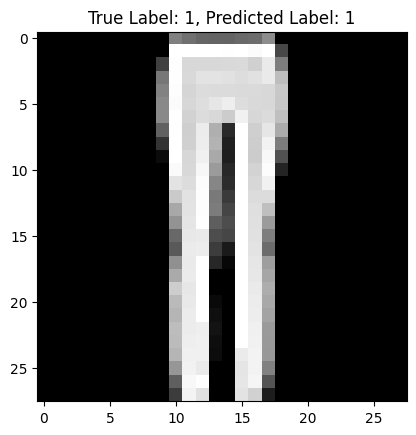

In [ ]:
# Load the saved VAE model weights
vae.load_state_dict(torch.load('vae_weights.pth', map_location=device))
vae.eval()
vae.to(device)  # Explicitly move the model to the GPU

# Load the saved SVM model
svm_model = joblib.load('svm_model_3000.pkl')

# Get a random image from the test loader
random_image_index = random.randint(0, len(test_dataset) - 1)
random_image, true_label = test_dataset[random_image_index]

# Extract latent features using the VAE
with torch.no_grad():
    random_image_gpu = random_image.unsqueeze(0).to(device)  # Move to GPU for inference
    _, mu, _ = vae(random_image_gpu)
    latent_feature = mu.cpu().numpy()

# Use the SVM to predict the class
predicted_label = svm_model.predict(latent_feature)

print(f"True label: {true_label}")
print(f"Predicted label: {predicted_label[0]}")

# Display the image
# Move the image back to CPU and convert to numpy
random_image_cpu = random_image.cpu().numpy()

# Reshape and display using matplotlib
plt.imshow(random_image_cpu.squeeze(), cmap='gray') # Assuming grayscale image
plt.title(f"True Label: {true_label}, Predicted Label: {predicted_label[0]}")
plt.show()